➡️ X shape: (1033, 3871),  y shape: (1033,)
➡️ Sample columns: ['product_size_bp', 'primer_score', 'tm_c', 'computed_tm_c', 'computed_gc_content', 'gRNA_emb_0', 'gRNA_emb_1', 'gRNA_emb_2', 'gRNA_emb_3', 'gRNA_emb_4']
⚙  Used sv[:,:,1], shape: (207, 3871)

🔍 Top 10 features by mean |SHAP|:
                     feature  mean_abs_shap
2953   target_region_emb_388       0.017758
2922   target_region_emb_357       0.014281
3655  target_region_emb_1090       0.012946
3544   target_region_emb_979       0.010728
3199   target_region_emb_634       0.010022
1233           gRNA_emb_1228       0.009748
3364   target_region_emb_799       0.009220
3698  target_region_emb_1133       0.008925
3735  target_region_emb_1170       0.007623
3250   target_region_emb_685       0.007555


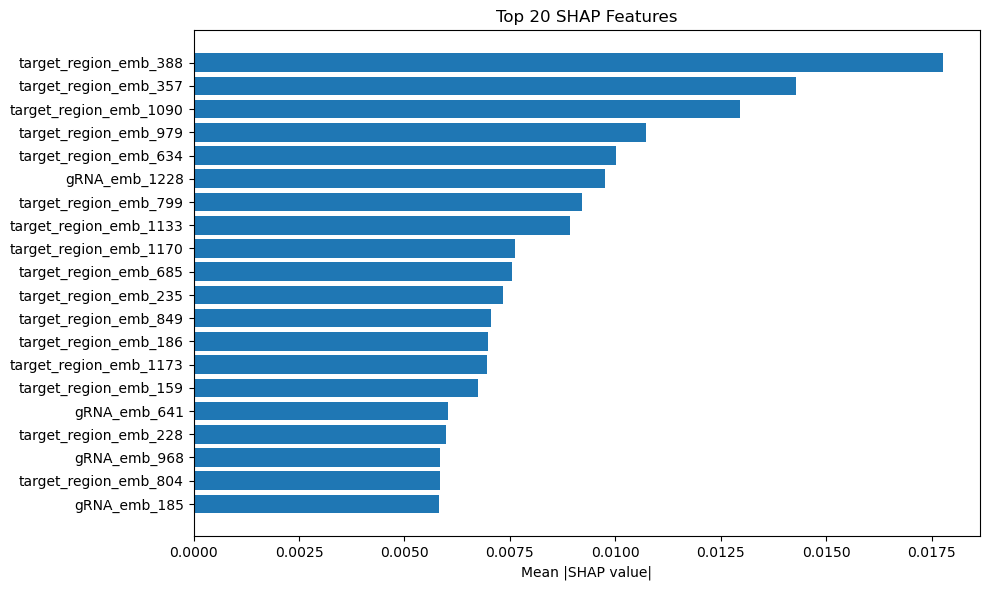

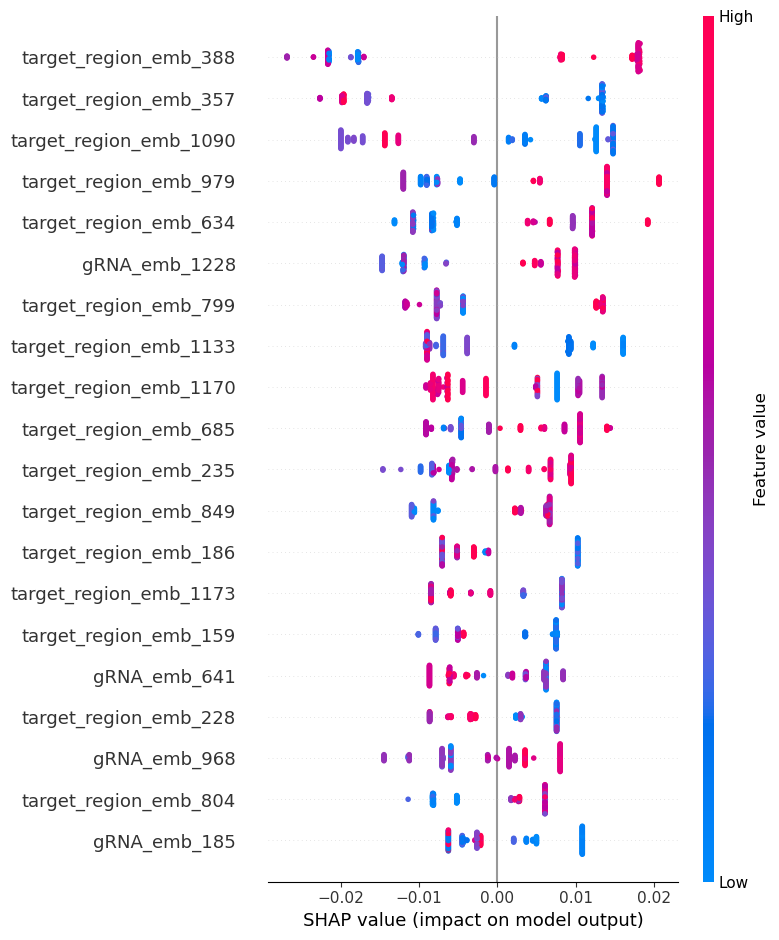

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap

# 1) load
merged_path = '/Users/ds39/Documents/Sunny/MAVE/RD_projects/Embedding/experimental_with_embeddings.csv'
df = pd.read_csv(merged_path)

# 2) build binary target (40% threshold)
y = (df['Average_mapped_reads'] > 40).astype(int)

# 3) drop unwanted columns
to_drop = [
    'Hdr Vector Lot', 'Pass Fail',
    'D4R1 Mapped Reads','D4R2 Mapped Reads','D4R3 Mapped Reads',
    'HDR_nanodrop (ng/ul)','gRNA_nanodrop (ng/ul)',
    'Average_mapped_reads',
    'Targeton','Targeton Name'
]
df2 = df.drop(columns=[c for c in to_drop if c in df.columns], errors='ignore')

# 4) select only numeric columns (this grabs your embeddings automatically)
X = df2.select_dtypes(include=[np.number])
print(f"➡️ X shape: {X.shape},  y shape: {y.shape}")
print("➡️ Sample columns:", list(X.columns[:10]))

# 5) train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# 6) fit RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

# 7) compute SHAP values
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_valid)

# 8) extract the class-1 contributions
if isinstance(sv, list):
    # binary classification returns [array_class0, array_class1]
    shap_vals = sv[1]
    print("⚙  Used shap_values[1], shape:", shap_vals.shape)
elif isinstance(sv, np.ndarray) and sv.ndim == 3:
    # multiclass contiguous: shape (n_samples, n_features, n_classes)
    shap_vals = sv[:, :, 1]
    print("⚙  Used sv[:,:,1], shape:", shap_vals.shape)
else:
    # maybe a single 2D array
    shap_vals = sv
    print("⚙  Used raw shap_values, shape:", shap_vals.shape)

# sanity check
assert isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 2, (
    f"Expected shap_vals to be 2D, got shape {shap_vals.shape}"
)

# 9) compute mean absolute SHAP per feature
mean_abs = np.abs(shap_vals).mean(axis=0)
assert mean_abs.shape[0] == X_valid.shape[1], "Feature count mismatch!"
fi = pd.DataFrame({
    'feature': X_valid.columns,
    'mean_abs_shap': mean_abs
}).sort_values('mean_abs_shap', ascending=False)

print("\n🔍 Top 10 features by mean |SHAP|:")
print(fi.head(10))

# 10) barplot top-20
top20 = fi.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1])
plt.title("Top 20 SHAP Features")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# 11) beeswarm summary
shap.summary_plot(shap_vals, X_valid, feature_names=X_valid.columns, plot_type='dot')



In [20]:
import pandas as pd
import numpy as np
import re

# 1) load your merged df (with embeddings + known features)
df = pd.read_csv('/Users/ds39/Documents/Sunny/MAVE/RD_projects/Embedding/experimental_with_embeddings.csv')

# 2) pick your “known” features
known = [
    'computed_gc_content',
    'computed_tm_c',
    'primer_score',
    'Average_Cell_Count',
    '%_Surviving_Cells',
    'HDR_Qubit(ng/ul)',
    'gRNA_Qubit (ng/ul)',
    '%_Successful_Edited_Cells'
]

# 3) find all the embedding columns
emb_cols = [c for c in df.columns if c.startswith('gRNA_emb_') or c.startswith('target_region_emb_')]

# 4) build a correlation table
corrs = []
for dim in emb_cols:
    row = {'dim': dim}
    for k in known:
        valid = df[[dim, k]].dropna()
        row[f"r_{k}"] = valid[dim].corr(valid[k])
    corrs.append(row)
corr_df = pd.DataFrame(corrs)

# 5) save the full correlation table
corr_df.to_csv("embedding_correlations_full.csv", index=False)

# 6) save per‐feature top10 pos/neg into separate CSVs with safe filenames
def slugify(name):
    # replace non-alphanumeric characters with underscore
    return re.sub(r'[^\w]+', '_', name).strip('_')

for k in known:
    col = f"r_{k}"
    sub = corr_df[['dim', col]].dropna()
    top_pos = sub.nlargest(10, columns=col).assign(which='top10_pos')
    top_neg = sub.nsmallest(10, columns=col).assign(which='top10_neg')
    out = pd.concat([top_pos, top_neg], ignore_index=True)
    fname = f"top10_corr_{slugify(k)}.csv"
    out.to_csv(fname, index=False)

print("✅ Written:\n - embedding_correlations_full.csv\n - top10_corr_<feature>.csv for each known feature") 



✅ Written:
 - embedding_correlations_full.csv
 - top10_corr_<feature>.csv for each known feature


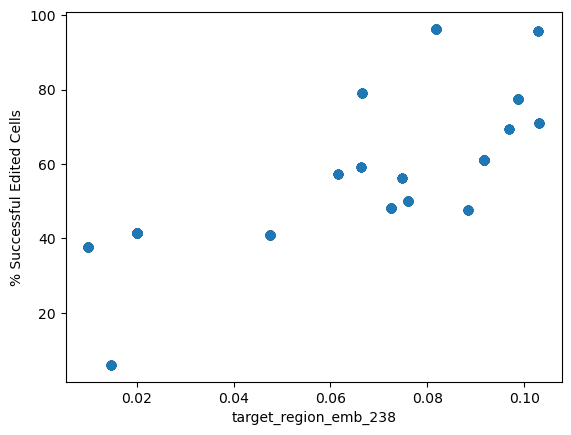

In [21]:
import matplotlib.pyplot as plt
plt.scatter(df['target_region_emb_238'], df['%_Successful_Edited_Cells'], alpha=0.5)
plt.xlabel('target_region_emb_238')
plt.ylabel('% Successful Edited Cells')
plt.show()


In [22]:
import pandas as pd
import numpy as np

# load
df = pd.read_csv("/Users/ds39/Documents/Sunny/MAVE/RD_projects/Embedding/experimental_with_embeddings.csv")

# your “known” features & how many dims to pick per feature
known = {
    "computed_gc_content":    ("GC-axis",        3),
    "computed_tm_c":          ("Tm-axis",        3),
    "Average_Cell_Count":     ("Viability-axis", 3),
    "HDR_Qubit(ng/ul)":       ("HDR-axis",       3),
    "gRNA_Qubit (ng/ul)":     ("gRNA-axis",      3),
    "%_Successful_Edited_Cells": ("Editing-axis", 3),
}

# find embedding dims
emb = [c for c in df if c.startswith("gRNA_emb_") or c.startswith("target_region_emb_")]

# build correlations
corrs = {}
for feat,(label,k) in known.items():
    rs = df[emb].corrwith(df[feat]).sort_values(ascending=False)
    corrs[label] = list(rs.index[:k])  # top k positive dims

# Flatten into a DataFrame of “axis_name → dim names”
axis_map = {axis: dims for axis,dims in corrs.items()}
print(axis_map)


{'GC-axis': ['target_region_emb_910', 'target_region_emb_96', 'target_region_emb_303'], 'Tm-axis': ['gRNA_emb_616', 'gRNA_emb_910', 'gRNA_emb_30'], 'Viability-axis': ['target_region_emb_371', 'target_region_emb_354', 'target_region_emb_995'], 'HDR-axis': ['target_region_emb_24', 'target_region_emb_799', 'target_region_emb_769'], 'gRNA-axis': ['target_region_emb_210', 'target_region_emb_771', 'target_region_emb_3'], 'Editing-axis': ['target_region_emb_238', 'target_region_emb_201', 'target_region_emb_303']}


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# build axis-scores
for axis, dims in axis_map.items():
    df[axis] = df[dims].mean(axis=1)

# binary target
df["y"] = (df["Average_mapped_reads"] >= 40).astype(int)

X = df[list(axis_map)]
y = df["y"]

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)
model = LogisticRegression().fit(X_train, y_train)
print("Val accuracy:", model.score(X_val, y_val))


Val accuracy: 0.7053140096618358


In [44]:
import os
import numpy as np
import pandas as pd

from sklearn.impute         import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.metrics        import accuracy_score
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.svm            import SVC
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model   import LogisticRegression

# 1) Load & prepare
df = pd.read_csv("/Users/ds39/Documents/Sunny/MAVE/RD_projects/Embedding/experimental_with_embeddings.csv")
y  = (df["Average_mapped_reads"] > 40).astype(int)

# drop unwanted
to_drop = [
    "Hdr Vector Lot","Pass Fail",
    "D4R1 Mapped Reads","D4R2 Mapped Reads","D4R3 Mapped Reads",
    "HDR_nanodrop (ng/ul)","gRNA_nanodrop (ng/ul)",
    "Average_mapped_reads",
    "Targeton","Targeton Name"
]
df_feats = df.drop(columns=[c for c in to_drop if c in df.columns], errors="ignore")

# numeric features (embeddings + experimental)
X = df_feats.select_dtypes(include=[np.number])
# drop any columns that are entirely NaN
X = X.drop(columns=X.columns[X.isna().all()])
# impute remaining NaNs by median
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# 2) build integer group IDs from the raw sequence columns
df["gRNA_id"]          = df["gRNA"].astype("category").cat.codes
df["target_region_id"] = df["target_region"].astype("category").cat.codes

# 3) define your models
classifiers = {
    'KNN (5)'          : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'        : SVC(kernel='rbf', probability=True, random_state=0),
    'Random Forest'    : RandomForestClassifier(n_estimators=100, random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
    'Logistic Regr.'   : LogisticRegression(max_iter=500, random_state=0),
}

def eval_grouped(X, y, groups, clf, n_splits=5):
    """Run GroupKFold and return list of accuracies."""
    gkf, accs = GroupKFold(n_splits=n_splits), []
    for tr_idx, te_idx in gkf.split(X, y, groups):
        clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = clf.predict(X.iloc[te_idx])
        accs.append(accuracy_score(y.iloc[te_idx], preds))
    return accs

# 4) run both “leave-one-sequence-out” evaluations
results = []
for col, split_name in [("gRNA_id", "Leave-one-gRNA-out"),
                        ("target_region_id", "Leave-one-target-out")]:
    print(f"\n=== {split_name} ===")
    for name, clf in classifiers.items():
        accs = eval_grouped(X_imp, y, df[col], clf)
        results.append({
            "Split"   : split_name,
            "Model"   : name,
            "Mean Acc": np.mean(accs),
            "Std Acc" : np.std(accs)
        })
        print(f"{name:20s}  {np.mean(accs):.3f} ± {np.std(accs):.3f}")

# 5) save summary
out_df = pd.DataFrame(results)
os.makedirs("model_outputs", exist_ok=True)
out_df.to_csv("model_outputs/grouped_results.csv", index=False)
print("\nSaved to model_outputs/grouped_results.csv")



=== Leave-one-gRNA-out ===
KNN (5)               0.533 ± 0.307
SVM (RBF)             0.882 ± 0.113
Random Forest         0.309 ± 0.351
Gradient Boosting     0.269 ± 0.378
Logistic Regr.        1.000 ± 0.000

=== Leave-one-target-out ===
KNN (5)               0.567 ± 0.175
SVM (RBF)             0.897 ± 0.092
Random Forest         0.269 ± 0.213
Gradient Boosting     0.564 ± 0.242
Logistic Regr.        0.891 ± 0.172

Saved to model_outputs/grouped_results.csv


In [113]:
import os
import numpy as np
import pandas as pd

from sklearn.impute          import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.metrics        import accuracy_score
from sklearn.linear_model   import LogisticRegression

# ── 1) Load & target ────────────────────────────────────────────────────────────
df = pd.read_csv("/Users/ds39/Documents/Sunny/MAVE/RD_projects/Embedding/experimental_with_embeddings.csv")
y  = (df["Average_mapped_reads"] >= 40).astype(int)

# ── 2) Drop unwanted columns ─────────────────────────────────────────────────────
drop_cols = [
    "Hdr Vector Lot","Pass Fail",
    "D4R1 Mapped Reads","D4R2 Mapped Reads","D4R3 Mapped Reads",
    "HDR_nanodrop (ng/ul)","gRNA_nanodrop (ng/ul)",
    "Average_mapped_reads",
    "Targeton","Targeton Name"
]
df2 = df.drop(columns=drop_cols, errors="ignore")

# ── 3) Identify numeric columns and drop any that are 100% NaN ────────────────────
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
# drop all-NaN columns
numeric_cols = [c for c in numeric_cols if not df2[c].isna().all()]

# split those into your three scenarios
gRNA_cols  = [c for c in numeric_cols if c.startswith("gRNA_emb_")]
targ_cols  = [c for c in numeric_cols if c.startswith("target_region_emb_")]
exp_cols   = [c for c in numeric_cols if c not in gRNA_cols + targ_cols]

scenarios = {
    "gRNA_only" : gRNA_cols + exp_cols,
    "targ_only" : targ_cols + exp_cols,
    "combined"  : gRNA_cols + targ_cols + exp_cols
}

# ── 4) Build group‐IDs so no sequence ever leaks ─────────────────────────────────
df["gRNA_id"]          = df["gRNA"].astype("category").cat.codes
df["target_region_id"] = df["target_region"].astype("category").cat.codes

# ── 5) Impute once on exactly those numeric_cols ────────────────────────────────
imp = SimpleImputer(strategy="median")
X_full = pd.DataFrame(
    imp.fit_transform(df2[numeric_cols]),
    columns = numeric_cols,      # ← use the same list you imputed
    index   = df2.index
)

# ── 6) Prepare CV & classifier ─────────────────────────────────────────────────
gkf = GroupKFold(n_splits=5)
clf = LogisticRegression(max_iter=1000, random_state=0)

results = []
for name, cols in scenarios.items():
    X = X_full[cols]
    for grp_col, split_name in [
        ("gRNA_id",          "Leave-one-gRNA-out"),
        ("target_region_id", "Leave-one-target-region-out")
    ]:
        accs = []
        for tr, te in gkf.split(X, y, groups=df[grp_col]):
            clf.fit(X.iloc[tr], y.iloc[tr])
            accs.append(accuracy_score(y.iloc[te], clf.predict(X.iloc[te])))
        results.append({
            "Scenario":  name,
            "Split":     split_name,
            "MeanAcc":   np.mean(accs),
            "StdAcc":    np.std(accs)
        })
        print(f"{name:12s} | {split_name:25s} → {np.mean(accs):.3f} ± {np.std(accs):.3f}")

# ── 7) Save your grouped‐CV summary ─────────────────────────────────────────────
os.makedirs("model_outputs", exist_ok=True)
pd.DataFrame(results).to_csv("model_outputs/scenario_grouped_accuracy.csv", index=False)
print("\nSaved to model_outputs/scenario_grouped_accuracy.csv")



gRNA_only    | Leave-one-gRNA-out        → 1.000 ± 0.000
gRNA_only    | Leave-one-target-region-out → 0.891 ± 0.172
targ_only    | Leave-one-gRNA-out        → 1.000 ± 0.000
targ_only    | Leave-one-target-region-out → 0.891 ± 0.172
combined     | Leave-one-gRNA-out        → 1.000 ± 0.000
combined     | Leave-one-target-region-out → 0.891 ± 0.172

Saved to model_outputs/scenario_grouped_accuracy.csv
